In [19]:
from sklearn.datasets import load_diabetes
dataset = load_diabetes()

In [20]:
dataset

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

In [21]:
print(dataset["DESCR"])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [23]:
X=pd.DataFrame(dataset.data, columns=["age", "sex", "BMI", "BP", "S1", "S2", "S3", "S4", "S5", "S6"])

In [24]:
y=dataset.target

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

In [26]:
X_train.corr()

,age,sex,BMI,BP,S1,S2,S3,S4,S5,S6
age,1.000000,0.197408,0.198359,0.394903,0.238375,0.192920,-0.128403,0.227110,0.314151,0.351570
sex,0.197408,1.000000,0.108261,0.221914,0.057674,0.180315,-0.379464,0.324882,0.150956,0.193322
BMI,0.198359,0.108261,1.000000,0.356324,0.226047,0.248146,-0.395021,0.412826,0.435505,0.358273
BP,0.394903,0.221914,0.356324,1.000000,0.238295,0.165632,-0.192505,0.249141,0.420236,0.368882
S1,0.238375,0.057674,0.226047,0.238295,1.000000,0.872781,0.006313,0.559626,0.566312,0.356280
S2,0.192920,0.180315,0.248146,0.165632,0.872781,1.000000,-0.265114,0.684840,0.325759,0.315890
S3,-0.128403,-0.379464,-0.395021,-0.192505,0.006313,-0.265114,1.000000,-0.754616,-0.370523,-0.297055
S4,0.227110,0.324882,0.412826,0.249141,0.559626,0.684840,-0.754616,1.000000,0.609983,0.436311
S5,0.314151,0.150956,0.435505,0.420236,0.566312,0.325759,-0.370523,0.609983,1.000000,0.490970
S6,0.351570,0.193322,0.358273,0.368882,0.356280,0.315890,-0.297055,0.436311,0.490970,1.000000


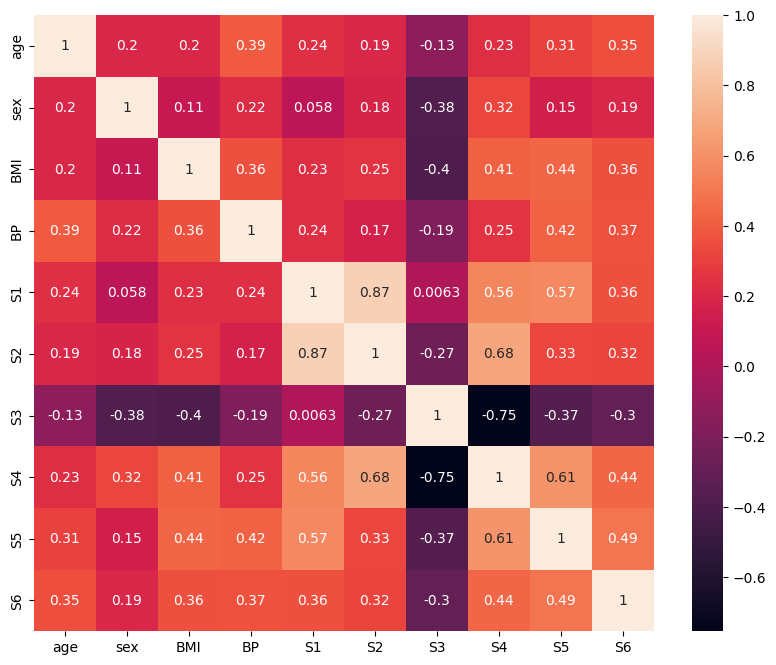

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(X_train.corr(), annot=True)
plt.show()

In [28]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor()
regressor.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [29]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    'splitter': ['best', 'random'],
    'max_depth': [1, 2, 3, 4, 5, 6, 10, 15, 20, 25],
    'max_features': ['auto', 'sqrt', 'log2']
}
grid=GridSearchCV(DecisionTreeRegressor(),param_grid,cv=5,scoring="neg_mean_squared_error")

In [30]:
grid.fit(X_train,y_train)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
400 fits failed out of a total of 1200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
400 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1356, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c

,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'friedman_mse'


In [31]:
print(grid.best_params_)

{'criterion': 'friedman_mse', 'max_depth': 6, 'max_features': 'sqrt', 'splitter': 'random'}


In [32]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [33]:
y_pred=grid.predict(X_test)

In [34]:
print('R2 Score:', r2_score(y_test, y_pred))
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))

R2 Score: 0.2733473278828251
Mean Absolute Error: 55.4787350502996
Mean Squared Error: 4598.019109482748


In [36]:
best=DecisionTreeRegressor(criterion="friedman_mse",max_depth= 4, max_features='sqrt', splitter= 'best')

In [37]:
best.fit(X_train,y_train)

,criterion,'friedman_mse'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [38]:
new_pred=best.predict(X_test)

In [40]:
print('R2 Score:', r2_score(y_test, new_pred))
print('Mean Absolute Error:', mean_absolute_error(y_test, new_pred))
print('Mean Squared Error:', mean_squared_error(y_test, new_pred))

R2 Score: 0.36745106241715453
Mean Absolute Error: 49.78790665388962
Mean Squared Error: 4002.561628535419


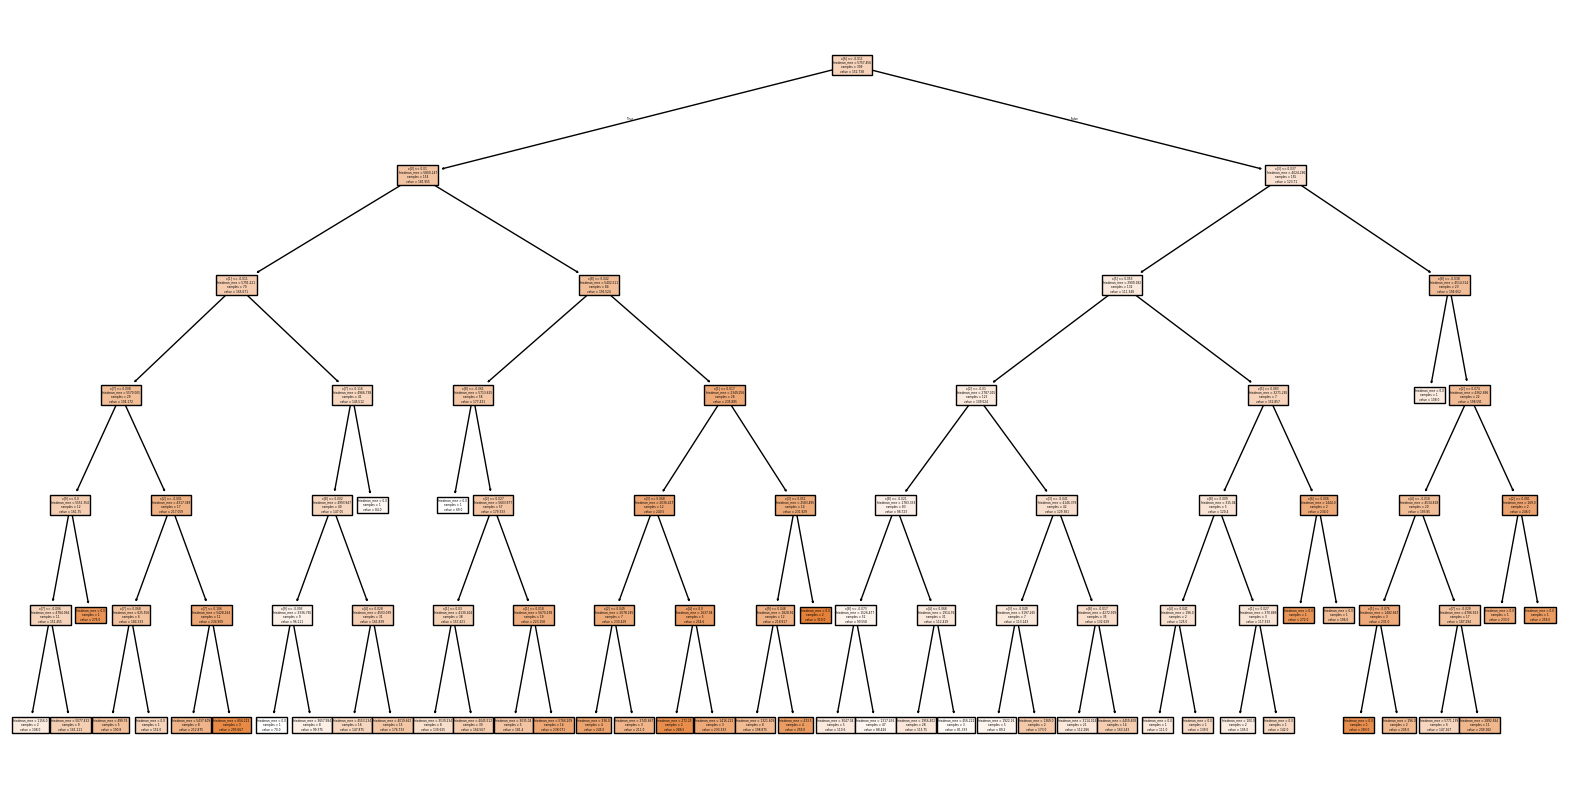

In [41]:
from sklearn import tree
plt.figure(figsize=(20,10))
tree.plot_tree(grid.best_estimator_, filled=True)
plt.show()

[223.         223.61111111 140.1        144.         157.44444444
 157.44444444  98.86607143 279.41176471  98.86607143  98.86607143
  98.86607143 140.1        120.8125      98.86607143  98.86607143
 223.61111111  98.86607143  98.86607143 120.8125      98.86607143
 157.44444444 269.5         98.86607143 279.41176471  98.86607143
  98.86607143 157.44444444 234.27272727 223.61111111 157.44444444
 234.27272727 142.5         98.86607143  98.86607143 223.61111111
 157.44444444  98.86607143 269.5        279.41176471 157.44444444
 234.27272727  98.86607143 120.8125      98.86607143  98.86607143
  98.86607143  98.86607143  98.86607143 279.41176471  98.86607143
 140.1         98.86607143 157.44444444 212.         223.61111111
 157.44444444  98.86607143 144.         157.44444444 144.
 140.1         98.86607143  98.86607143  98.86607143  98.86607143
 223.61111111 120.8125     144.         157.44444444  98.86607143
 223.61111111 157.44444444  98.86607143  98.86607143 234.27272727
 223.61111111 140.